In [2]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.animation import FuncAnimation
from collections import defaultdict
from water_sim_basic import step_simulation, compute_vertex_normals_and_volume, generate_polyhedron, generate_rectangular_cube_mesh

ImportError: cannot import name 'step_simulation' from 'water_sim_basic' (/Users/olam23/Desktop/UC Berkeley/Spring 2026/CS 184/CS184-final-project/python_sim_dev/water_sim_basic.py)

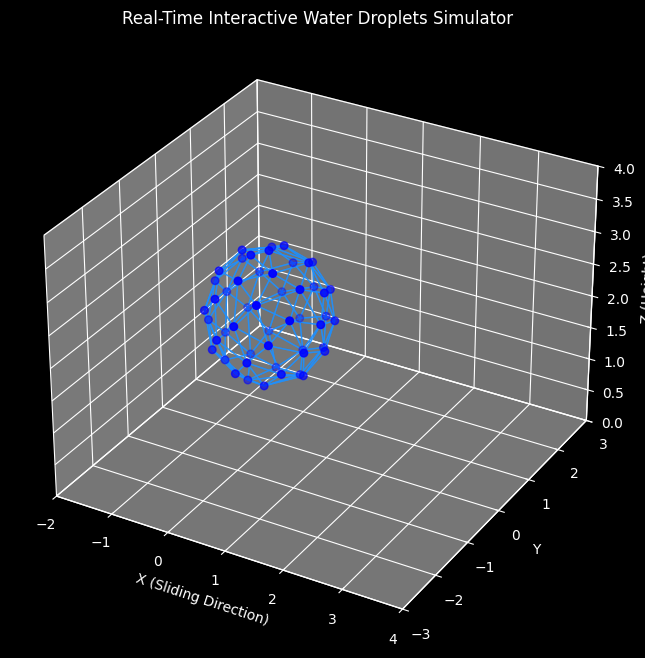

In [ ]:
def init_sim():
    x, faces, neighbours = generate_polyhedron(n_vertices=50, radius=1.0)
    # x, faces, neighbours = generate_rectangular_cube_mesh(length=2.0)
    v = np.zeros_like(x)
    _, V_0 = compute_vertex_normals_and_volume(x, faces)
    x += np.array([0, 0, 2.0]) # Drop height
    return x, v, neighbours, faces, V_0

x, v, neighbours, faces, V_0 = init_sim()

# Simulation Settings
dt = 0.008
sub_steps = 8
sub_dt = dt / sub_steps

# Rendering Setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

def get_edge_segments(x, faces):
    return x[faces[:, [0, 1, 1, 2, 2, 0]]].reshape(-1, 2, 3)

lines = Line3DCollection(get_edge_segments(x, faces), colors="dodgerblue", linewidths=1.0, alpha=0.7)
ax.add_collection3d(lines)
sc = ax.scatter(x[:, 0], x[:, 1], x[:, 2], c="blue", s=30)

ax.set(xlim=(-2, 4), ylim=(-3, 3), zlim=(0, 4), 
       xlabel="X (Sliding Direction)", ylabel="Y", zlabel="Z (Height)",
       title="Real-Time Interactive Water Droplets Simulator")

def update_anim(frame):
    """
    Geometry:
    - n_vertices (Resolution): Higher = smoother deformations but requires smaller dt for stability; Lower = blocky but fast.

    Forces & Dynamics:
    - gamma (Surface Tension): Higher = stiffer, spherical droplet; Lower = flattens into a loose puddle.
    - mu (Global Damping): Overall viscosity. Higher = loses momentum quickly (thick fluid); Lower = bouncy/elastic.
    - eta (Laplacian Viscosity): Surface damping. Higher = smooth, unified surface movement; Lower = allows localized ripples/waves.
    - k_v (Volume Stiffness): Incompressibility constraint. Higher = fiercely resists volume change; Lower = slowly deflates.
    - friction_coeff (Friction): Surface adhesion. Higher = sticky, resists sliding; Lower = slippery, slides easily.
    """

    global x, v
    
    # Internal sub-stepping for numerical stability
    for _ in range(sub_steps):
        v, x = step_simulation(
            v, x, faces, neighbours, V_0,
            method="euler",
            dt=sub_dt, g=np.array([0.0, 0.0, -9.81]),
            gamma=50.0,  # higher tension to preserve bead shape
            mu=3.0,        # numerically safer damping than very large explicit mu
            eta=0.08,      # keep Laplacian viscosity in a stable/recommended range
            k_v=2000.0,
            rho=0.050,    # lower density to allow more visible deformation without extreme forces
            alpha=0.5,     # contact angle stiffness
            friction_coeff=0.2,
            contact_angles=(np.deg2rad(105.0), np.deg2rad(125.0)),
            # contact_angles=(np.deg2rad(85.0), np.deg2rad(95.0)),
            # contact_angles=(np.deg2rad(10.0), np.deg2rad(20.0)),
            volume_correction_mode="both",
        )
        
    sc._offsets3d = (x[:, 0], x[:, 1], x[:, 2])
    lines.set_segments(get_edge_segments(x, faces))
    return sc, lines

In [ ]:
ani = FuncAnimation(fig, update_anim, frames=500, interval=1, blit=True)

try:
    from IPython.display import display, HTML
    import matplotlib
    matplotlib.rcParams['animation.embed_limit'] = 600.0
    display(HTML(ani.to_jshtml()))
    plt.close()
except ImportError:
    plt.show()

/Users/meli/Desktop/Kevin/UCB/CS 184/CS184-final-project/python_sim_dev/water_sim_basic.py:16: RuntimeWarning: invalid value encountered in divide
  return np.where(norm > 0, vec / norm, vec)
